###  Installation de l'environnement

In [30]:
#%pip install -r requirements.txt

In [31]:
%pip install plotly-express

Note: you may need to restart the kernel to use updated packages.


In [32]:
%pip install tensorflow keras-tuner scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [33]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [34]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [35]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [36]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 6 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_events_11_2019
5. user_segments_11_2019_kmeans
6. user_segments_kmeans


### Import de la table DuckDB

In [37]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events_11_2019"
TABLE_SEGMENTS = "user_segments_11_2019"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [38]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────────────┐
│             name             │
│           varchar            │
├──────────────────────────────┤
│ all_events                   │
│ loaded_files                 │
│ user_events                  │
│ user_events_11_2019          │
│ user_segments_11_2019_kmeans │
│ user_segments_kmeans         │
└──────────────────────────────┘



In [39]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} ORDER BY RANDOM() LIMIT 30000
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events_11_2019 table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬─────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │   purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │       double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼─────────────────────┼───────────────────────┤
│ 535496160 │           12 │        12.0 │             0.0 │      196613.363

In [40]:
# Drop the datetime column
user_events_df = user_events_df.drop(columns=["last_event_time"])

In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélectionner les features numériques uniquement
numeric_features = user_events_df.select_dtypes(include=[np.number])

# Option 1: Standardisation (Z-score normalization) - moyenne=0, écart-type=1
print("Standardisation des données...")
std_scaler = StandardScaler()
X_standardized = std_scaler.fit_transform(numeric_features)

X_num_scaled = X_standardized

Standardisation des données...


In [42]:
# Replace for Using category embeddings
#X_final = np.hstack([X_num_scaled, X_emb_scaled])
X_final = X_num_scaled  # Use scaled numerical features instead of raw dataframe


Trial 1/12
Clustering score: 19.73916070359486

Trial 2/12
Clustering score: 18.605344596833834

Trial 3/12
Clustering score: 18.352010434639173

Trial 4/12
Clustering score: 10.141945375899482

Trial 5/12
Clustering score: 15.062975491880707

Trial 6/12
Clustering score: 23.358988690176922

Trial 7/12
Clustering score: 16.69541296009161

Trial 8/12
Clustering score: 19.919309896151358

Trial 9/12
Clustering score: 11.385283746064404

Trial 10/12
Clustering score: 12.884874899578806

Trial 11/12
Clustering score: 23.094001662812733

Trial 12/12
Clustering score: 10.234211501205593

BEST SCORE: 23.358988690176922
Best model summary:


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,133 (4.43 KB)

 Trainable params: 377 (1.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 756 (2.96 KB)

None

BEST HYPERPARAMETERS:
Learning Rate: 0.0010000000474974513

BEST HYPERPARAMETERS:
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step

FINAL CLUSTER QUALITY
Silhouette: 0.5612006783485413
Calinski-Harabasz: 23637.744452485673
Davies-Bouldin: 0.8399564406572922
Cluster Stability (ARI): 0.484019755145996


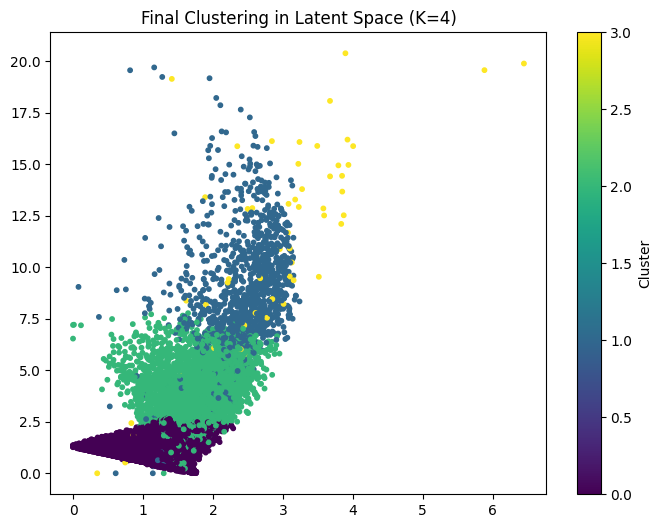

In [43]:
# ===============================
# 0. IMPORTS
# ===============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# X_scaled must already exist
# X_scaled = your standardized dataset
K_target = 4
X_scaled = X_final
# ===============================
# 1. AUTOENCODER BUILDER
# ===============================

def build_autoencoder(hp):

    input_dim = X_scaled.shape[1]
    inputs = layers.Input(shape=(input_dim,))
    x = inputs

    # ----- Encoder -----
    num_layers = hp.Int('num_layers', 1, 3)

    for i in range(num_layers):
        x = layers.Dense(
            units=hp.Int(f'units_{i}', 16, 64, step=16),
            activation='relu'
        )(x)

        if hp.Boolean(f'dropout_{i}'):
            x = layers.Dropout(0.2)(x)

    latent_dim = hp.Int('latent_dim', 2*K_target, 5*K_target)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_space')(x)

    # ----- Decoder -----
    outputs = layers.Dense(input_dim, activation='linear')(latent)

    model = keras.Model(inputs, outputs)

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )

    return model


# ===============================
# 2. CLUSTERING QUALITY FUNCTION
# ===============================

def clustering_score(X_latent):

    kmeans = KMeans(
        n_clusters=K_target,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=42
    ).fit(X_latent)

    labels = kmeans.labels_

    sil = silhouette_score(X_latent, labels)
    ch  = calinski_harabasz_score(X_latent, labels)
    db  = davies_bouldin_score(X_latent, labels)

    # Normalize CH scale
    score = sil + ch/1000 - db

    return score


# ===============================
# 3. CUSTOM HYPERPARAM SEARCH
# ===============================

best_score = -np.inf
best_model = None

trials = 12   # increase for stronger tuning

for t in range(trials):

    print(f"\nTrial {t+1}/{trials}")

    hp = kt.HyperParameters()
    model = build_autoencoder(hp)

    model.fit(
        X_scaled, X_scaled,
        epochs=40,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # ----- Extract encoder -----
    encoder = keras.Model(
        inputs=model.input,
        outputs=model.get_layer('latent_space').output
    )

    X_latent = encoder.predict(X_scaled, verbose=0)

    score = clustering_score(X_latent)

    print("Clustering score:", score)

    # Modify at line with "if score > best_score:"
    if score > best_score:
        best_score = score
        best_model = model
        best_hp = hp  # Store the hyperparameters object

print("\nBEST SCORE:", best_score)
print("Best model summary:")
print(best_model.summary())

# Extract and display best hyperparameters
print("\nBEST HYPERPARAMETERS:")
best_hp = best_model.optimizer.get_config()
print(f"Learning Rate: {best_hp.get('learning_rate', 'N/A')}")
# Note: For comprehensive hyperparameter tracking, consider storing hp object during trials
print("\nBEST HYPERPARAMETERS:")



# ===============================
# 4. FINAL LATENT SPACE
# ===============================

encoder = keras.Model(
    inputs=best_model.input,
    outputs=best_model.get_layer('latent_space').output
)

X_latent = encoder.predict(X_scaled)


# ===============================
# 5. FINAL KMEANS
# ===============================

final_kmeans = KMeans(
    n_clusters=K_target,
    n_init=100,
    max_iter=1000,
    random_state=42
)

final_clusters = final_kmeans.fit_predict(X_latent)


# ===============================
# 6. METRICS
# ===============================

sil = silhouette_score(X_latent, final_clusters)
ch  = calinski_harabasz_score(X_latent, final_clusters)
db  = davies_bouldin_score(X_latent, final_clusters)

print("\nFINAL CLUSTER QUALITY")
print("Silhouette:", sil)
print("Calinski-Harabasz:", ch)
print("Davies-Bouldin:", db)



# ===============================
# 7. STABILITY TEST
# ===============================

labels_runs = []

for i in range(10):
    km = KMeans(n_clusters=K_target, random_state=i).fit(X_latent)
    labels_runs.append(km.labels_)

stability = np.mean([
    adjusted_rand_score(labels_runs[0], labels_runs[i])
    for i in range(1, 10)
])

print("Cluster Stability (ARI):", stability)


# ===============================
# 8. VISUALIZATION
# ===============================

plt.figure(figsize=(8,6))
plt.scatter(
    X_latent[:, 0],
    X_latent[:, 1],
    c=final_clusters,
    cmap='viridis',
    s=10
)
plt.title(f"Final Clustering in Latent Space (K={K_target})")
plt.colorbar(label='Cluster')
plt.show()

### Fit et Plot KMeans

In [44]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd


def kmeans_fit_and_plot_per_cluster(k, X_final, df):
    df_tmp = df.copy()
    #kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans = final_kmeans
    clusters = kmeans.fit_predict(X_final)
    df_tmp["segment"] = clusters

    # --- Silhouette Analysis ---
    print("Silhouette Analysis...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X_final, clusters)

    # Print silhouette score for each cluster
    for cluster in range(k):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")

    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}  # Map cluster index to color

    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {k}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()

    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)

    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)

    plt.title(f"Visualisation des clusters utilisateurs (PCA 2D)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)

    # Prepare data for Plotly
    traces = []
    for i in range(k):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],  # Use consistent cluster color
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-colorscale')

    return df_tmp

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_stats(df, segment_column="segment"):
    """
    Plots statistics, distributions, and boxplots for clusters in the DataFrame.

    Parameters:
    - df: DataFrame containing the clustering results and features.
    - segment_column: Name of the column containing cluster segments.

    Returns:
    - stats: A dictionary containing descriptive statistics for each cluster.
    """
    # Ensure the segment column exists
    if segment_column not in df.columns:
        raise ValueError(f"Column '{segment_column}' not found in the DataFrame.")

    # Number of individuals per cluster
    cluster_counts = df[segment_column].value_counts().sort_index()
    print("Number of individuals per cluster:")
    print(cluster_counts)

    # Plot the distribution of individuals per cluster
    plt.figure(figsize=(10, 6))
    cluster_counts.plot(kind="bar", color="skyblue", alpha=0.8)
    plt.title("Distribution of Individuals per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Descriptive statistics for each cluster
    stats = {}
    for cluster in cluster_counts.index:
        cluster_data = df[df[segment_column] == cluster]
        cluster_stats = cluster_data.describe()
        stats[cluster] = cluster_stats
        print(f"\nDescriptive statistics for Cluster {cluster}:")
        print(cluster_stats)

    # Boxplots for each column grouped by cluster
    numeric_columns = df.select_dtypes(include=["number"]).columns
    numeric_columns = [col for col in numeric_columns if col != segment_column]

    for col in numeric_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=segment_column, y=col, data=df, palette="Set3")
        plt.title(f"Boxplot of {col} by Cluster")
        plt.xlabel("Cluster")
        plt.ylabel(col)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

    return stats

Silhouette Analysis...
For n_clusters = 4, the average silhouette_score is: 0.27601961657535257
Silhouette score for Cluster 0: 0.23141108454576115
Silhouette score for Cluster 1: 0.03685624961509635
Silhouette score for Cluster 2: 0.22640920686530586
Silhouette score for Cluster 3: 0.3818406758578058


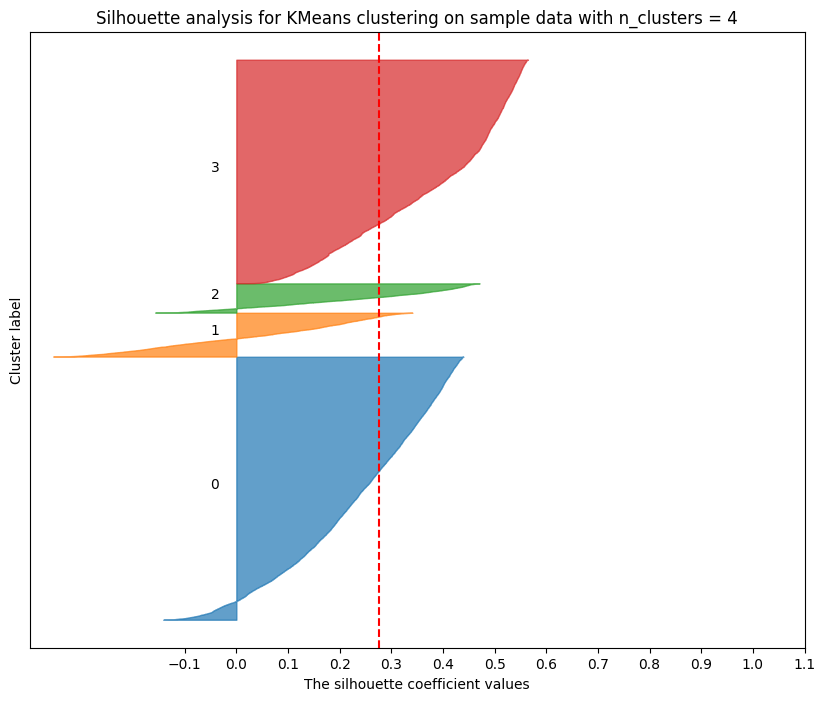

Visualisation du clustering (2D)...


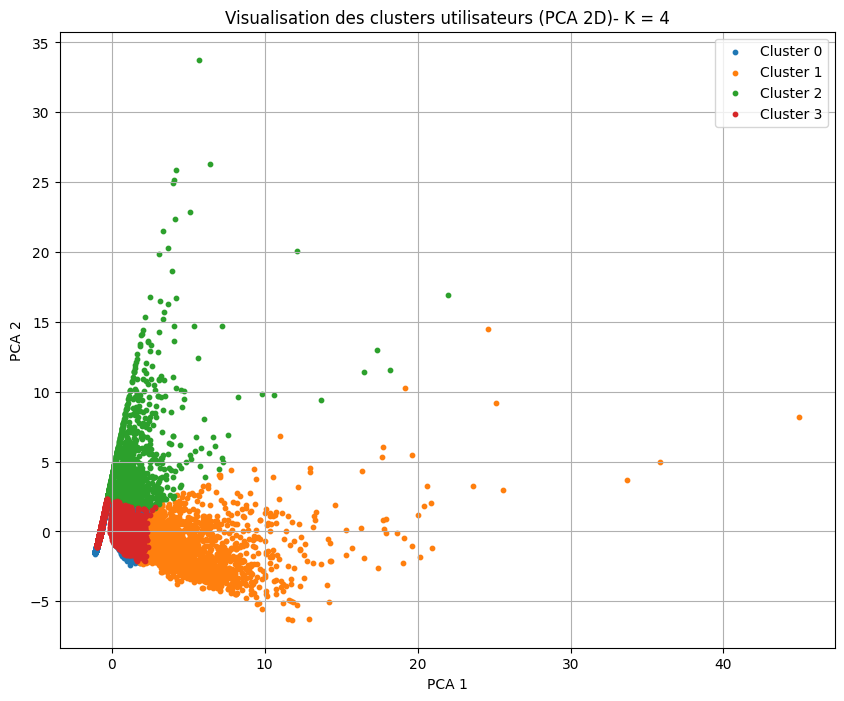

Visualisation du clustering (3D)...


In [46]:
N_CLUSTERS = 4

df_kmeans = kmeans_fit_and_plot_per_cluster(N_CLUSTERS, X_final, user_events_df)

In [47]:
df_kmeans["segment"].value_counts()

segment
0    14102
3    11985
1     2348
2     1565
Name: count, dtype: int64

Number of individuals per cluster:
segment
0    14102
1     2348
2     1565
3    11985
Name: count, dtype: int64


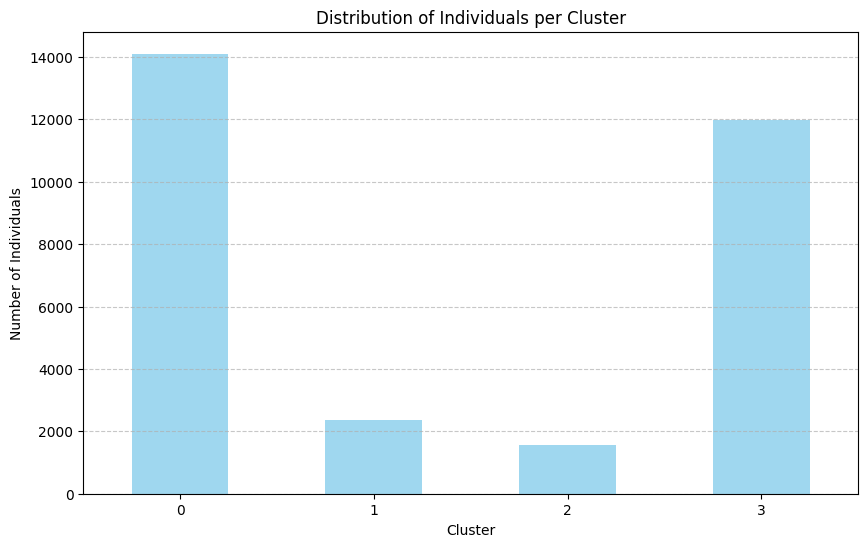


Descriptive statistics for Cluster 0:
       total_events   total_views  total_purchases  avg_time_between_events  \
count  14102.000000  14102.000000     14102.000000             14102.000000   
mean      35.450574     33.937030         0.260389             59783.596730   
std       27.358848     26.357048         0.631639             48966.380379   
min       10.000000      1.000000         0.000000                 3.140351   
25%       15.000000     14.000000         0.000000             23405.072503   
50%       25.000000     24.000000         0.000000             46616.181170   
75%       47.000000     45.000000         0.000000             85882.930195   
max      144.000000    132.000000         6.000000            281524.444444   

        total_spent    avg_basket  conversion_rate  purchase_ratio  \
count  14102.000000  14102.000000     14102.000000    14102.000000   
mean      40.313081     29.863915         0.008715        0.008167   
std      122.223022     87.985073      

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




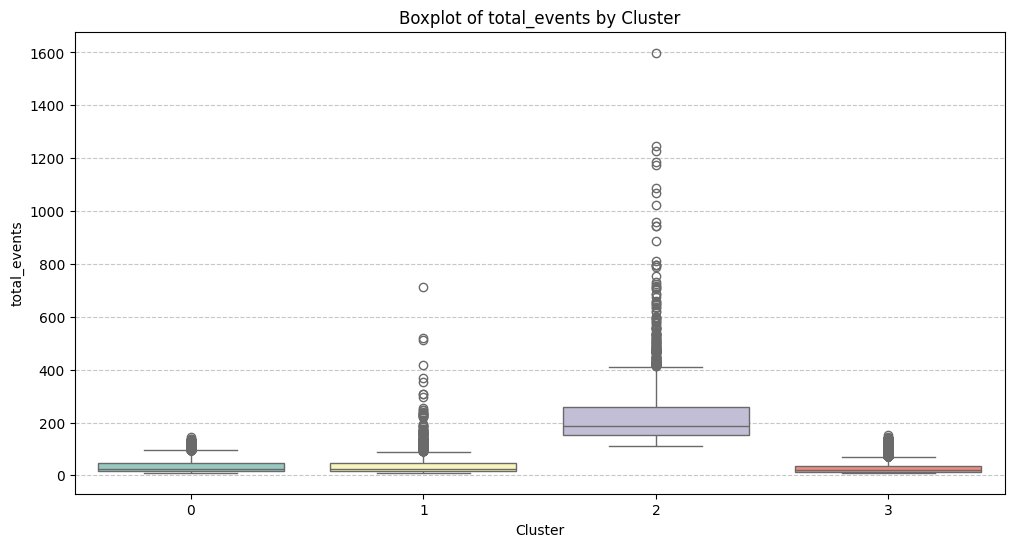

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




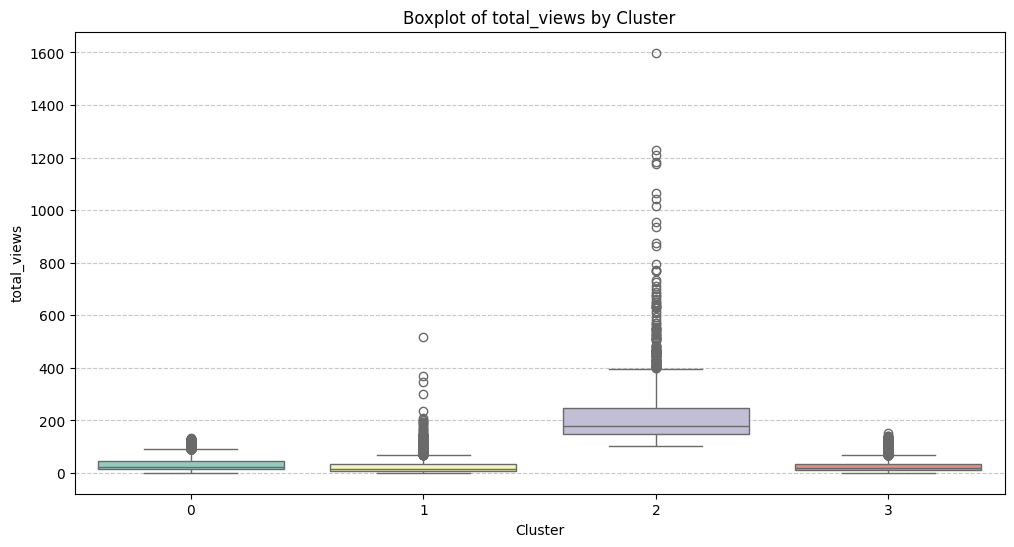

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




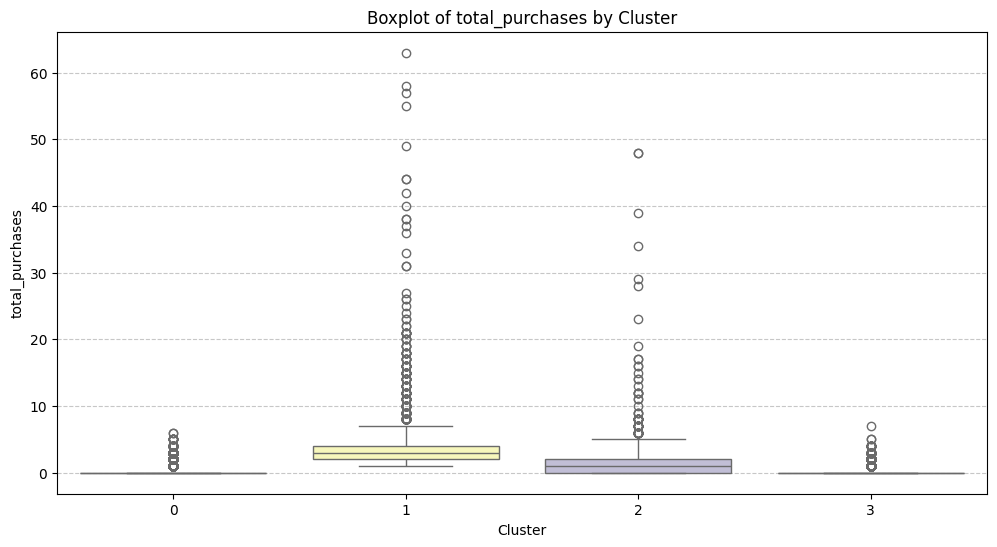

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




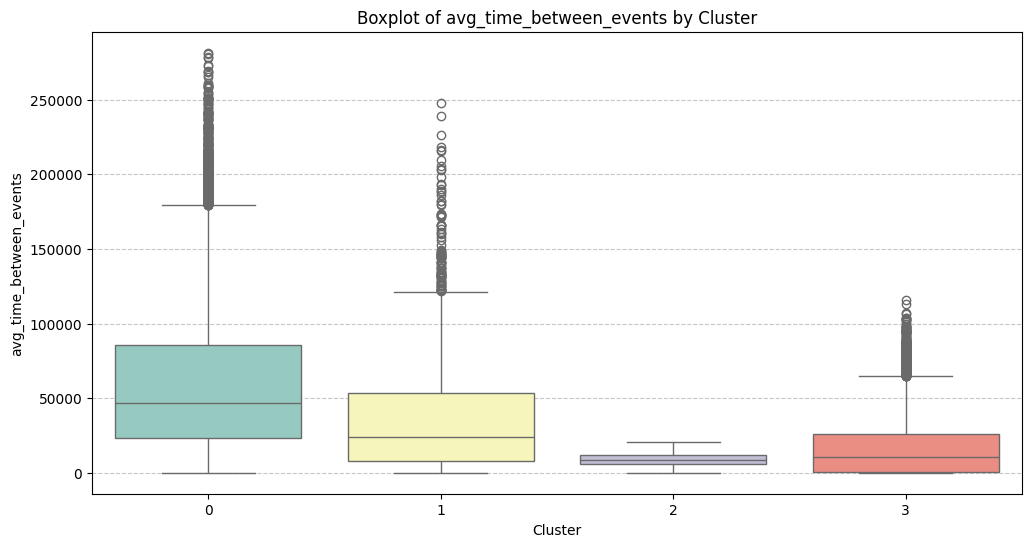

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




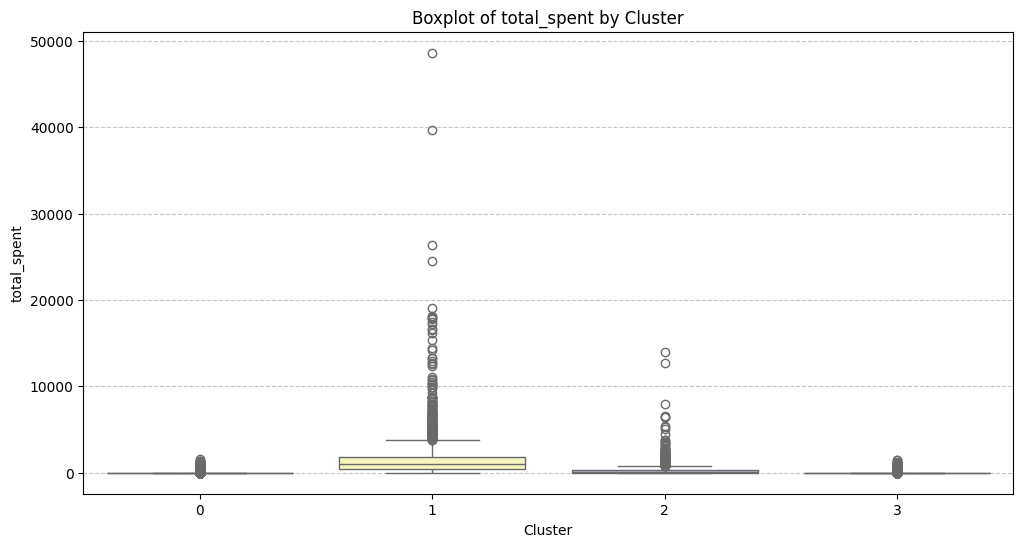

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




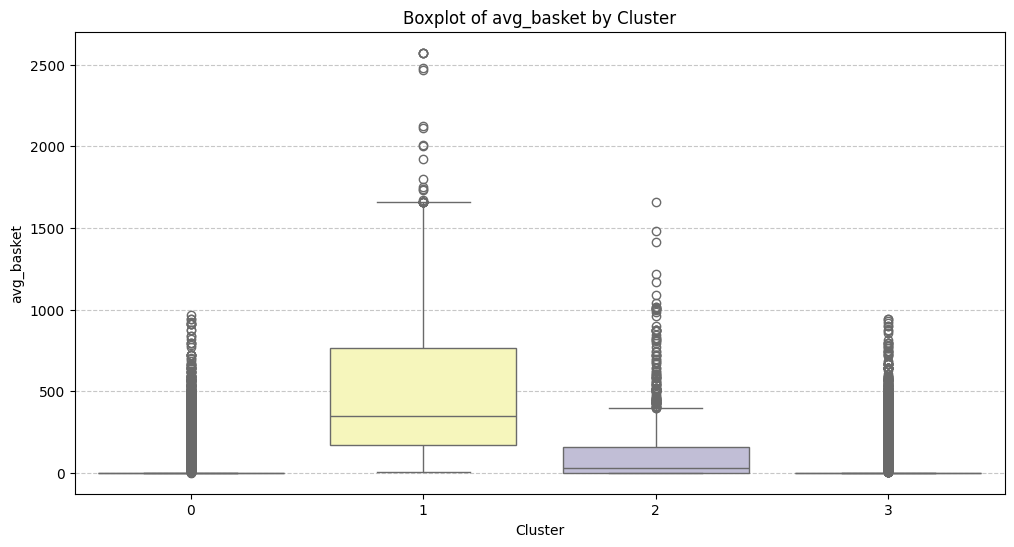

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




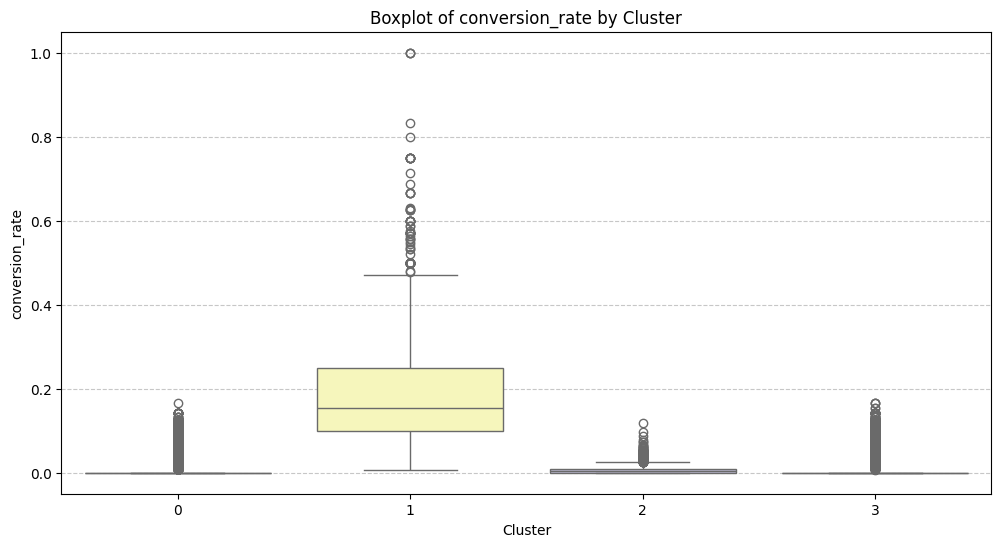

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




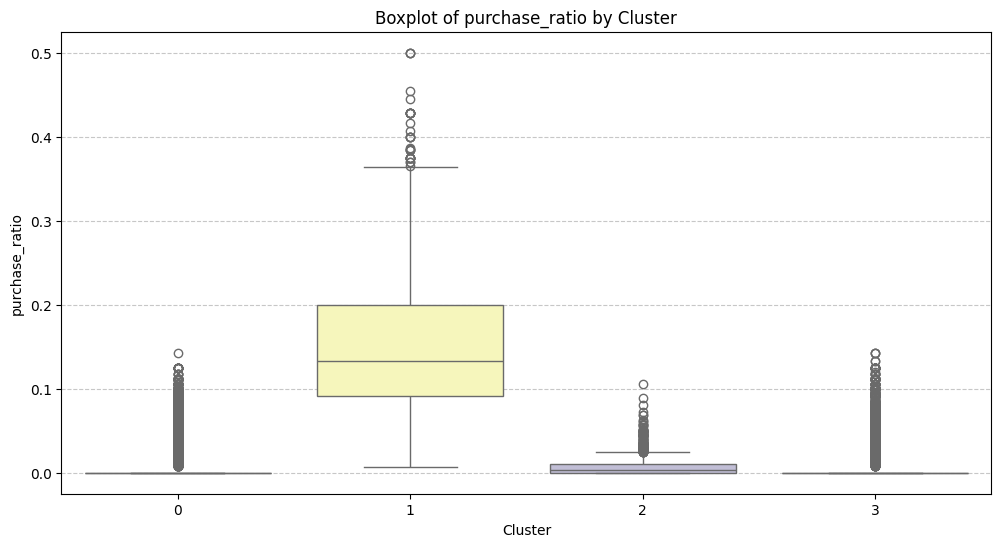

/tmp/ipykernel_411164/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




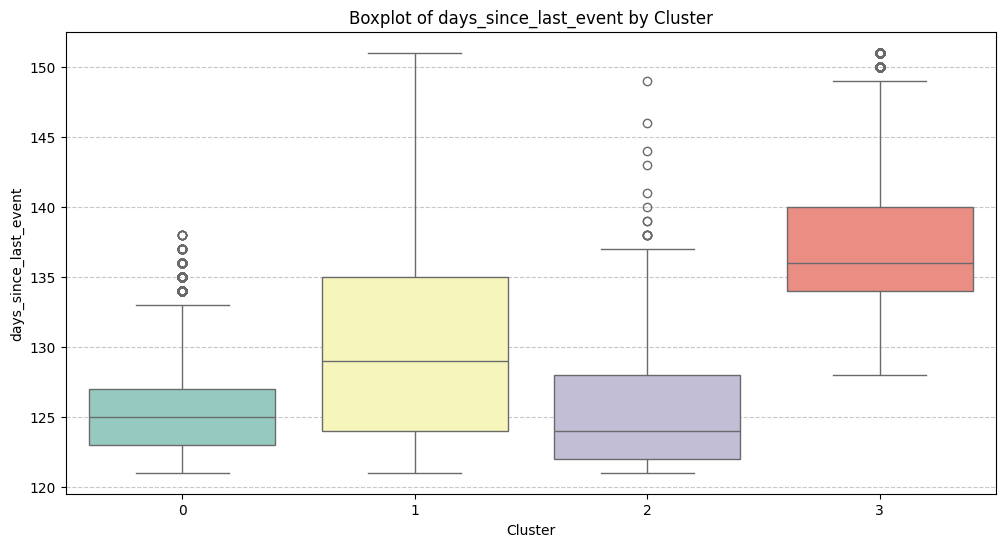

{0:        total_events   total_views  total_purchases  avg_time_between_events  \
 count  14102.000000  14102.000000     14102.000000             14102.000000   
 mean      35.450574     33.937030         0.260389             59783.596730   
 std       27.358848     26.357048         0.631639             48966.380379   
 min       10.000000      1.000000         0.000000                 3.140351   
 25%       15.000000     14.000000         0.000000             23405.072503   
 50%       25.000000     24.000000         0.000000             46616.181170   
 75%       47.000000     45.000000         0.000000             85882.930195   
 max      144.000000    132.000000         6.000000            281524.444444   
 
         total_spent    avg_basket  conversion_rate  purchase_ratio  \
 count  14102.000000  14102.000000     14102.000000    14102.000000   
 mean      40.313081     29.863915         0.008715        0.008167   
 std      122.223022     87.985073         0.022765        0.0

In [48]:
plot_cluster_stats(df_kmeans, segment_column="segment")

In [49]:
# Fermeture de la connexion DuckDB
con.close()